In [426]:
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain_openai import ChatOpenAI
from rich import print as rprint
#from rich.pretty import pprint
from pprint import pprint
import json
import requests


In [427]:
from langgraph.graph import StateGraph, END, MessagesState,START
from langchain.tools import tool
import datetime
from langchain_core.messages import HumanMessage,AIMessage,SystemMessage
from langgraph.prebuilt import ToolNode

In [428]:
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")


In [637]:

# from langchain_groq import ChatGroq  # Note: OpenRouter’s API is compatible with OpenAI-style clients
# llm = ChatGroq(
#     model="qwen/qwen3-coder-480b-a35b-instruct:free",  # or "qwen/qwen3-235b-a22b:free"
#     api_key=os.environ["GROQ_API_KEY"]
# )

In [639]:
model="qwen/qwen3-32b"
llm=ChatGroq(model=model)
response=llm.invoke("what is the capital of France")
print(response.content)

<think>
Okay, so the user is asking for the capital of France. Let me think. I remember from school that France is a country in Europe, and its capital is... Paris? Yeah, I think that's right. But wait, maybe they want more information? Like, maybe the population or something else? But the question is straightforward: just the capital. Let me confirm. I can recall that Paris is known for the Eiffel Tower, the Louvre, and it's a major city. I don't think Lyon or Marseille is the capital. Let me see, other countries in Europe: Germany's capital is Berlin, Italy's is Rome, so France would logically be Paris. Maybe double-check in my mind. Yes, Paris is definitely the capital. I think that's correct. No need to overcomplicate. Just answer Paris.
</think>

The capital of France is **Paris**.


In [640]:
from typing import Annotated
from rich import print as rprint
from rich.pretty import pretty_repr
import yfinance as yf

In [641]:
class State(MessagesState):
    next:str

In [642]:
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_community.tools.tavily_search import TavilySearchResults


In [643]:
#search_runner = DuckDuckGoSearchRun()
search_runner = TavilySearchResults(max_results=2)

@tool
def duckduckgo_search(query: str) -> str:
    """Run a real DuckDuckGo search"""
    return search_runner.run(query)

@tool
def current_time() -> str:
    """Get the current system time"""
    return datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")

@tool
def stocks(var_stock: str) -> str:
    """Get the last close price of a stock using yfinance"""
    stock = yf.Ticker(var_stock)
    price = stock.history(period="1d")['Close'].iloc[-1]
    return f"As of today, the stock price for {var_stock.upper()} is {price:.2f} USD."


@tool
def user_details(name: str):
    """Fetch user details from local API endpoint"""
    url = f"http://localhost:8000/v1/users?name={name}"
    print("this is URL -->",url)
    print(f"Fetching user details for user {name}")
    try:
        response = requests.get(url, timeout=5)
        response.raise_for_status()
        return response.json()  # returns list of dicts
    except requests.HTTPError as e:
        return {"error": f"HTTP {response.status_code}: User -->{name} not found."}
    except Exception as e:
        return {"error": str(e)}




In [644]:
# search_runner.invoke("What is the capital of France?")

In [645]:
def classify_tool(query: str) -> str:
    query_lower = query.lower()
    if "time" in query_lower or "date" in query_lower:
        return "time"
    elif any(word in query_lower for word in ["stock", "price", "share", "ticker"]):
        return "stock"
    else:
        return "duck"


In [689]:
def classify_tool(query: str) -> str:
    q = query.lower()
    if any(word in q for word in ["user", "details", "information about"]):
        return "user"
    elif "time" in q or "date" in q:
        return "time"
    elif any(word in q for word in ["stock", "price", "share", "ticker"]):
        return "stock"
    else:
        return "duck"



def decision_node(state: MessagesState):
    """Decide which tool to call based on user query"""
    query = state["messages"][-1].content
    
    # Improved LLM prompt
    decision_prompt = f"""
You are an agent deciding which tool to use for a user query. 

Query: "{query}"

Available tools:
- duck   → web search
- time   → current time/date
- stock  → stock price
- user   → fetch user details

Respond with **only one word**: duck, time, or stock.
Do not add any explanation, reasoning, or extra text.
"""
    
    # Ask LLM
    raw = llm.invoke(decision_prompt).content.strip().lower()
    
    # Extract last word only to avoid reasoning text
    decision_word = raw.split()[-1] if raw else ""
    
    # Validate LLM decision, fallback to classifier if invalid
    if decision_word in ["duck", "time", "stock"]:
        decision = decision_word
    else:
        decision = classify_tool(query)
    
    return {"decision": decision}


In [690]:
import re
def duck_node(state: MessagesState):
    query = state["messages"][-1].content
    result = duckduckgo_search.invoke(query)
    return {"messages": [AIMessage(content=f"[Tool: DuckDuckGo] {result}")]}


def time_node(state: MessagesState):
    result = current_time.invoke("")
    return {"messages": [AIMessage(content=f"[Tool: CurrentTime] {result}")]}


def stock_node(state: MessagesState):
    query = state["messages"][-1].content
    result = stocks.invoke(query)
    return {"messages": [AIMessage(content=f"[Tool: Stock] {result}")]}




def user_node(state: MessagesState):
    query = state["messages"][-1].content


    name_prompt = f"Extract the user name from this query: '{query}'. Respond with only the name."
    raw_name = llm.invoke(name_prompt).content.strip()


    without_think = re.sub(r"<think>.*?</think>", "", raw_name, flags=re.DOTALL).strip()

    lines = [line.strip() for line in without_think.splitlines() if line.strip()]
    name = lines[-1] if lines else "unknown"

    #name = re.sub(r'^[\'"`]+|[\'"`]+$', '', name).rstrip(",").strip()

    print(f"Extracted name: {name}") 
    if not name:
        name = "unknown"

    # Call the tool
    # print("i am type",type(name),raw_name,name)
    result = user_details.invoke(name)
    #print(f"Result from user_details tool: {result}")
    

    if isinstance(result, dict) and "error" in result:
        formatted_result = f"User {name} is not found nononnot in the history."
        
    elif isinstance(result, list) and len(result) > 0:
        formatted_result = ""
        for user in result:
            formatted_result += (
                f"Name: {user.get('name')}\n"
                f"Email: {user.get('email')}\n"
                f"Phone: {user.get('phoneNumber')}\n"
                f"Address: {user.get('address')}\n"
                f"ID: {user.get('id')}\n"
                "------------------------\n"
            )
    else:
        formatted_result = f"User {name} is not found or not in the history."

    return {"messages": [AIMessage(content=f"[Tool: UserDetails]\n{formatted_result}")] }


In [691]:
# name=arun
# user_details.invoke(name)

In [692]:
graph = StateGraph(MessagesState)

graph.add_node("decision", decision_node)
graph.add_node("duck", duck_node)
graph.add_node("time", time_node)
graph.add_node("stock", stock_node)
graph.add_node("user", user_node)




In [693]:
graph.add_edge(START, "decision")



In [694]:
graph.add_conditional_edges(
    "decision",
    lambda state: state["decision"],
    {
        "duck": "duck",
        "time": "time",
        "stock": "stock",
        "user": "user"
    }
)

In [695]:
graph.add_edge("duck", END)
graph.add_edge("time", END)
graph.add_edge("stock", END)


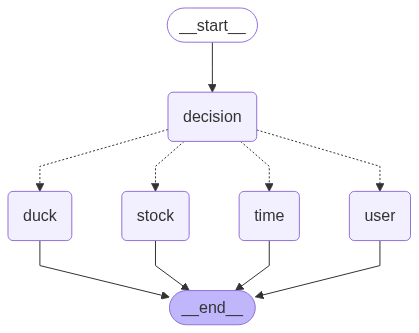

In [696]:
workflow=graph.compile()
from IPython.display import display,Image
display(Image(workflow.get_graph().draw_mermaid_png()))

In [697]:
# if __name__ == "__main__":
#     from langchain.schema import HumanMessage

#     config = {"configurable": {"thread_id": "user123"}}

#     # First turn
#     result = workflow.invoke(
#         {"messages": [HumanMessage(content="tell me about user Liam Evans")]},
#         config=config
#     )
#     print("Turn 1:", result["messages"][-1].content)

#     # Second turn (no need to pass old history)
#     result = workflow.invoke(
#         {"messages": [HumanMessage(content="What is the time now?")]},
#         config=config
#     )
#     print("Turn 2:", result["messages"][-1].content)

#     # Third turn
#     result = workflow.invoke(
#         {"messages": [HumanMessage(content="AAPL")]},
#         config=config
#     )
#     print("Turn 3:", result["messages"][-1].content)

In [698]:
from langchain.schema import HumanMessage
config = {"configurable": {"thread_id": "user123"}}
result = workflow.invoke(
       {"messages": [HumanMessage(content="tell me about user Liam Evans")]},
       config=config
  )
print(result["messages"][-1].content)

Extracted name: Liam Evans
this is URL --> http://localhost:8000/v1/users?name=Liam Evans
Fetching user details for user Liam Evans
[Tool: UserDetails]
Name: Liam Evans
Email: liam.evans@example.com
Phone: +13895953115
Address: 167 Cedar St, Greenville
ID: 96df717b-42e1-4eba-b5d5-f4b020b0f669
------------------------



In [699]:
# result = workflow.invoke({"messages": [{"role": "user", "content": "Search about LangGraph"}]})

In [700]:
# result=workflow.invoke({"messages": [{"role": "user", "content": "curent time"}]})


   

In [701]:
# result["messages"][-1].content  # Get the last message content

In [702]:
# for m in result["messages"]:
#     m.pretty_print()